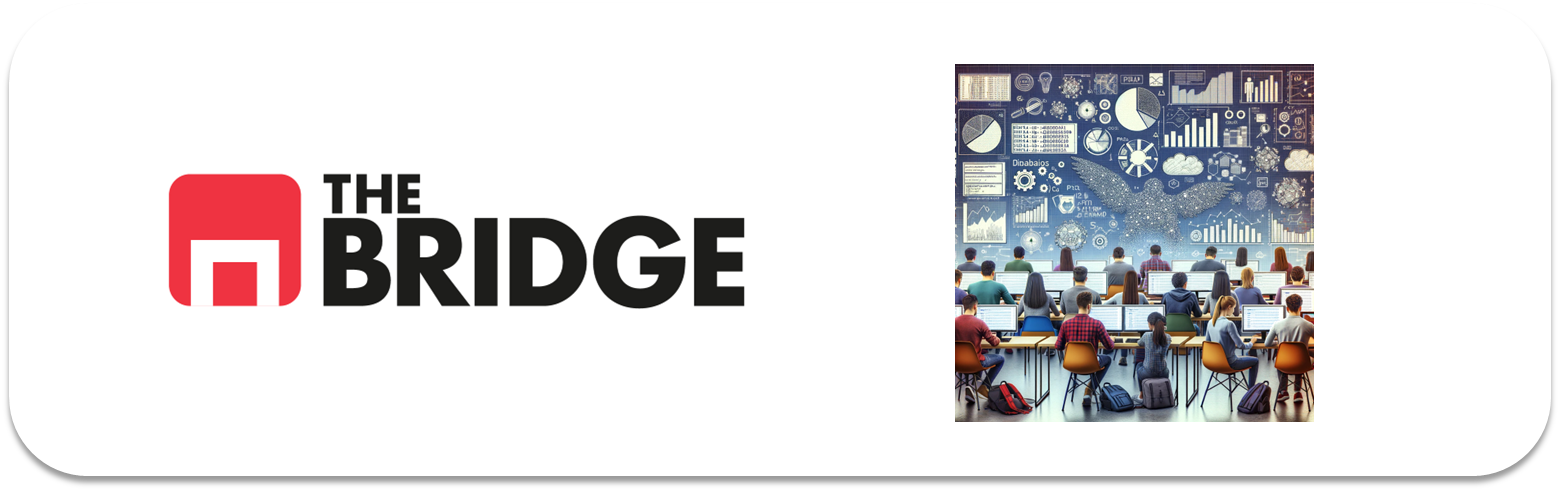

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [39]:
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
import pandas as pd
import sklearn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



In [40]:
df_titanic = pd.read_csv(r"C:\Users\pablo.moran\Documents\GitHub\DS-Online-Pablo-Moran\DS-Online-Pablo-Moran\04_Machine_Learning\Sprint_10\Unidad_02_ML_Supervisado_Clasificacion_Regresion_Logistica\03_Practica_Obligatoria\data\titanic.csv")
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [41]:
df = df_titanic.copy()

In [42]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [43]:
df_titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [44]:
df_titanic.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
target = "survived"

In [46]:
#eliminar columnas que no me sirven

excluidas = ["embark_town", "alive", "class", "adult_male"]


In [47]:
#detectar nulos de Deck

df_titanic.deck.value_counts(dropna=False, normalize=True)

deck
NaN    0.772166
C      0.066218
B      0.052750
D      0.037037
E      0.035915
A      0.016835
F      0.014590
G      0.004489
Name: proportion, dtype: float64

In [58]:
#relleno los nulos

df_deck = df_titanic.copy()
df_deck["deck"] = df_deck.deck.fillna("UNK")
df_deck.deck.value_counts( normalize=True)

deck
UNK    0.772166
C      0.066218
B      0.052750
D      0.037037
E      0.035915
A      0.016835
F      0.014590
G      0.004489
Name: proportion, dtype: float64

In [59]:
# creo las feautures base (menos las excluidas)

features_base = [col for col in df_deck.columns if col not in excluidas]
features_base.remove("deck")

In [60]:
features_base_deck = [col for col in df_deck.columns if col not in excluidas]

In [61]:
df_deck.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         891 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [62]:
df_deck.embarked.value_counts(dropna=False, normalize=True)

embarked
S      0.722783
C      0.188552
Q      0.086420
NaN    0.002245
Name: proportion, dtype: float64

In [64]:
#decido eliminar esas dos filas enteras

df_deck= df_deck.dropna(subset="embarked")

In [65]:
df_deck.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          712 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     889 non-null    object 
 8   class        889 non-null    object 
 9   who          889 non-null    object 
 10  adult_male   889 non-null    bool   
 11  deck         889 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        889 non-null    object 
 14  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 99.0+ KB


In [66]:
#ya hago el train y hago estratificado 

train_set, test_set = train_test_split(df_deck, test_size=0.2,
                                       random_state=73, stratify=df_deck["embarked"])

In [ ]:
#compruebo que está bien estratificado en ambas

train_set["embarked"].value_counts(normalize=True)

embarked
S    0.724332
C    0.188467
Q    0.087201
Name: proportion, dtype: float64

In [68]:
test_set["embarked"].value_counts(normalize=True)

embarked
S    0.724719
C    0.191011
Q    0.084270
Name: proportion, dtype: float64

In [69]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 455 to 162
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     711 non-null    int64  
 1   pclass       711 non-null    int64  
 2   sex          711 non-null    object 
 3   age          574 non-null    float64
 4   sibsp        711 non-null    int64  
 5   parch        711 non-null    int64  
 6   fare         711 non-null    float64
 7   embarked     711 non-null    object 
 8   class        711 non-null    object 
 9   who          711 non-null    object 
 10  adult_male   711 non-null    bool   
 11  deck         711 non-null    object 
 12  embark_town  711 non-null    object 
 13  alive        711 non-null    object 
 14  alone        711 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 79.2+ KB


In [70]:
#tengo nulos en age

es_hombre = train_set.who == "man"
es_mujer = train_set.who == "woman"
es_nino = train_set.who == "child"

median_man = train_set[es_hombre].age.median()
median_woman = train_set[es_mujer].age.median()
median_child = train_set[es_nino].age.median()

es_nulo = train_set.age.isna()
es_nulo_set = test_set.age.isna()

#imputamos en train

train_set.loc[es_nulo & es_hombre, "age"] = median_man
train_set.loc[es_nulo & es_mujer, "age"] = median_woman
train_set.loc[es_nulo & es_nino, "age"] = median_child

#imputamos en test

test_set.loc[es_nulo_set & es_hombre, "age"] = median_man
test_set.loc[es_nulo_set & es_mujer, "age"] = median_woman
test_set.loc[es_nulo_set & es_nino, "age"] = median_child

In [71]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 455 to 162
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     711 non-null    int64  
 1   pclass       711 non-null    int64  
 2   sex          711 non-null    object 
 3   age          711 non-null    float64
 4   sibsp        711 non-null    int64  
 5   parch        711 non-null    int64  
 6   fare         711 non-null    float64
 7   embarked     711 non-null    object 
 8   class        711 non-null    object 
 9   who          711 non-null    object 
 10  adult_male   711 non-null    bool   
 11  deck         711 non-null    object 
 12  embark_town  711 non-null    object 
 13  alive        711 non-null    object 
 14  alone        711 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 95.3+ KB


#MINI EDA

In [73]:
train_set[target].value_counts(normalize=True)

survived
0    0.620253
1    0.379747
Name: proportion, dtype: float64

In [74]:
train_set[features_base_deck].info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 455 to 162
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  711 non-null    int64  
 1   pclass    711 non-null    int64  
 2   sex       711 non-null    object 
 3   age       711 non-null    float64
 4   sibsp     711 non-null    int64  
 5   parch     711 non-null    int64  
 6   fare      711 non-null    float64
 7   embarked  711 non-null    object 
 8   who       711 non-null    object 
 9   deck      711 non-null    object 
 10  alone     711 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 78.0+ KB


In [ ]:
#separar features numéricas continuas

features_num = ["age", "fare", "sibsp", "parch"]


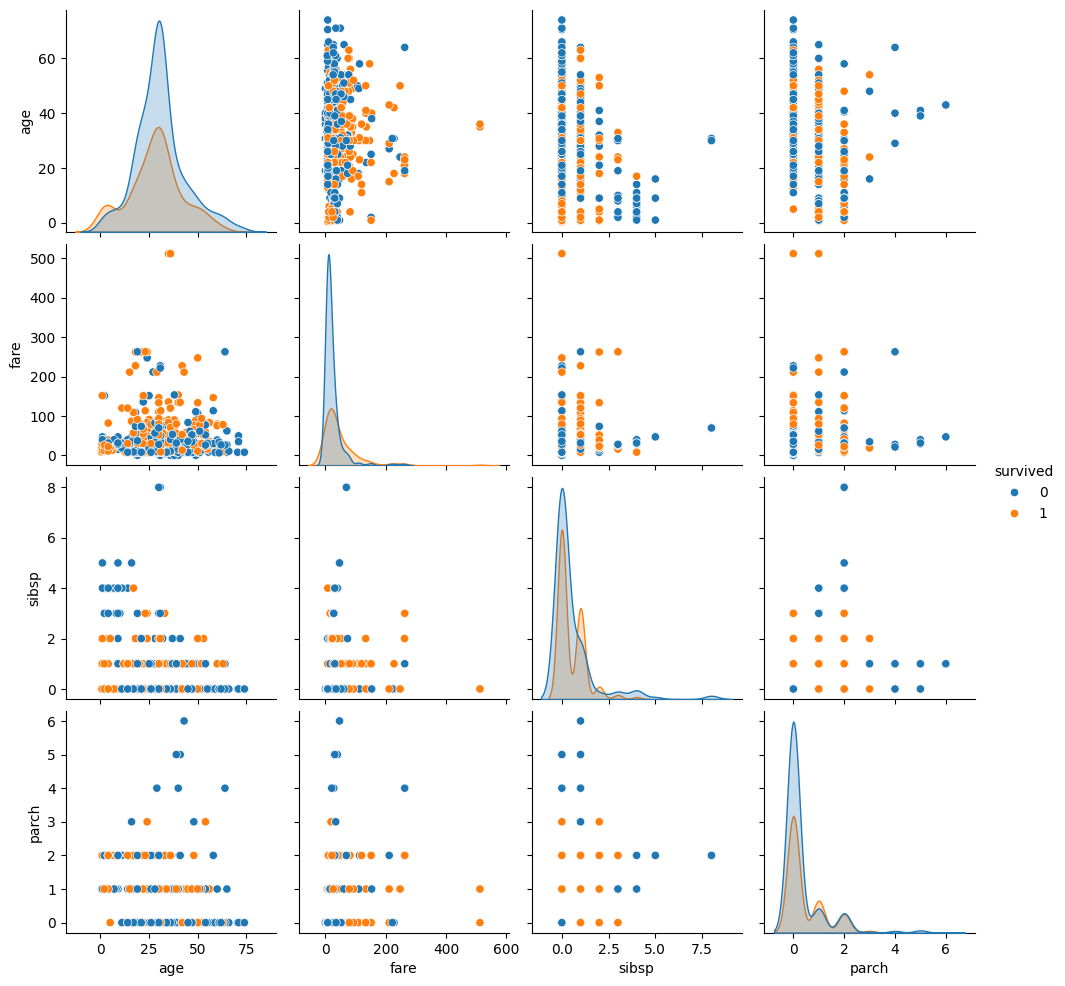

In [79]:
sns.pairplot(train_set[features_num + [target]], hue=target)

In [ ]:
#ME LLAMA LA ATENCIÓN PARCH... NO ME VA A DIFERENCIAR
#DESCARTAR PARCH

In [80]:
features_num = ["age", "fare", "sibsp"]

In [82]:
#VAMOS CON LAS CATEGÓRICAS
features_cat = ["pclass", "sex", "embarked", "alone", "who", "deck"]

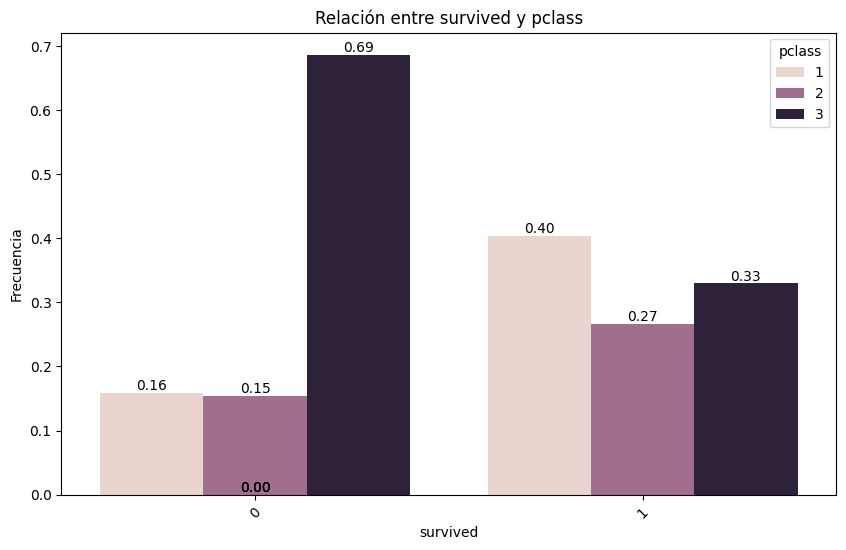

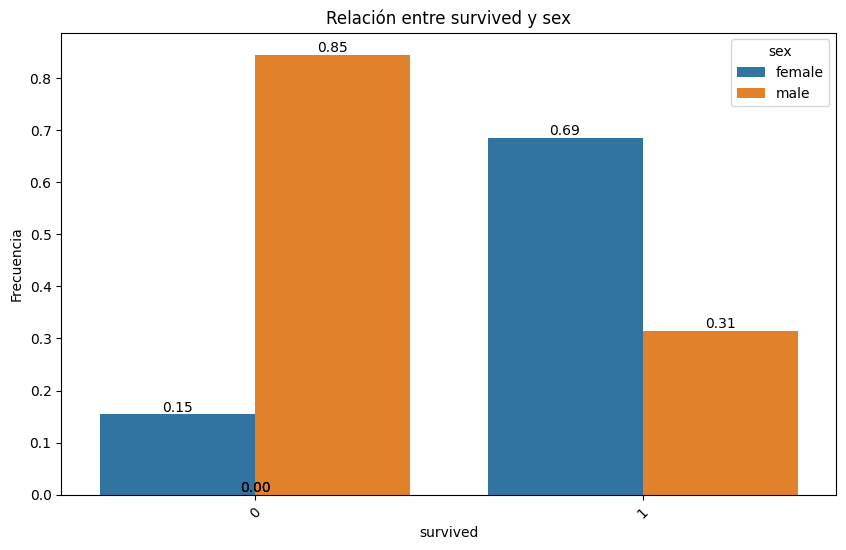

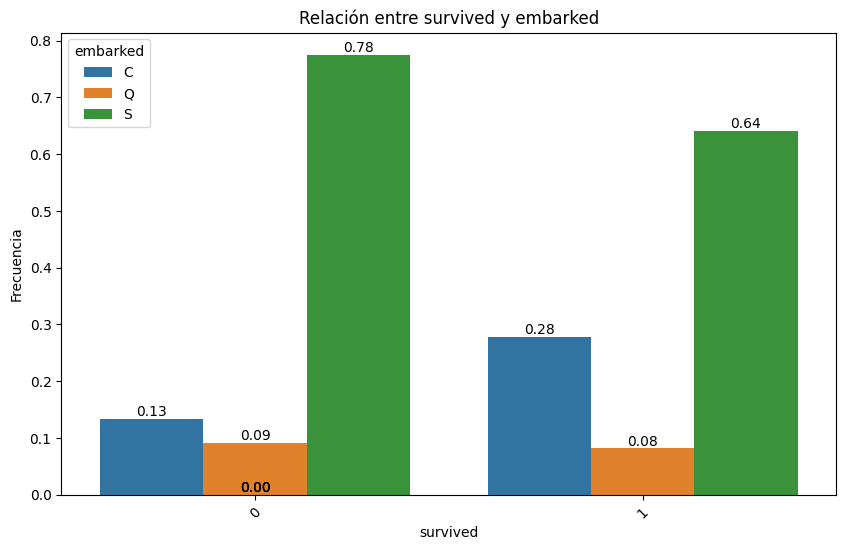

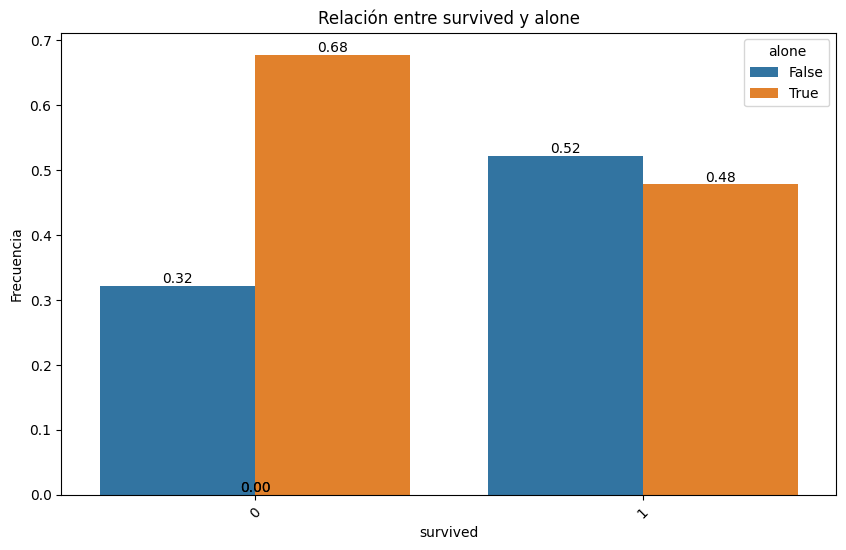

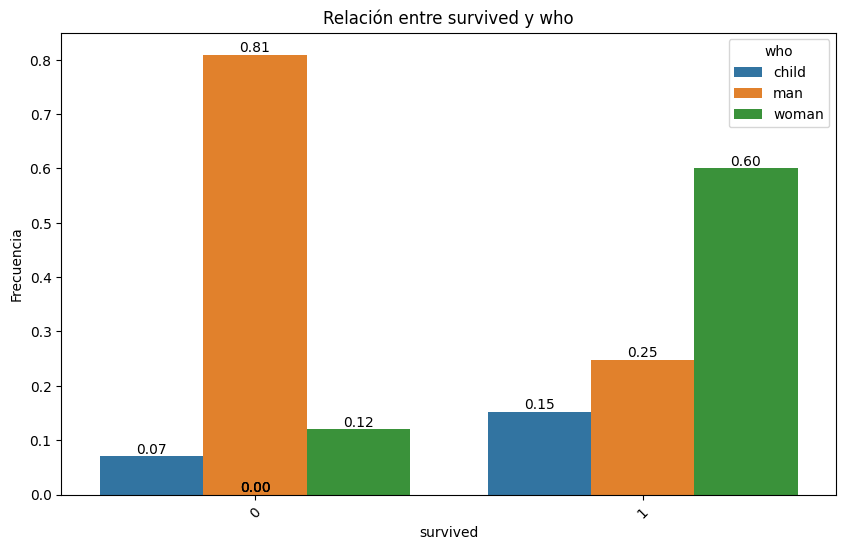

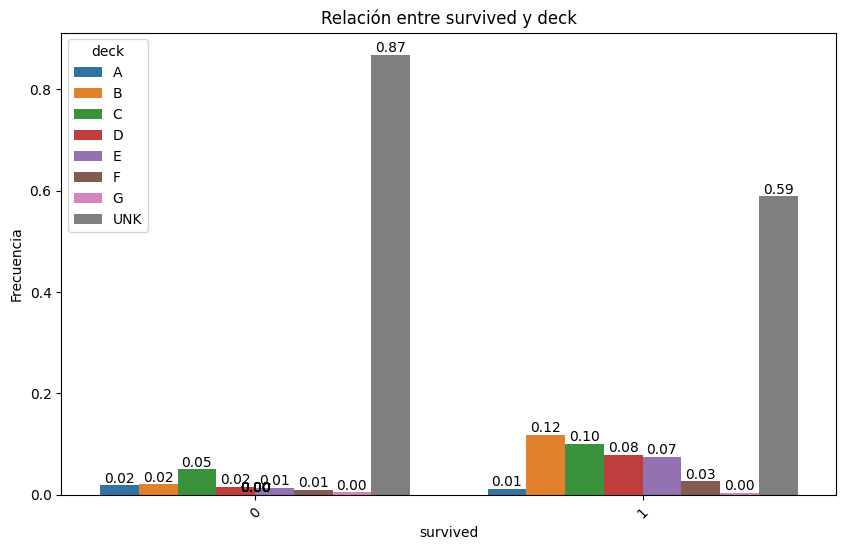

In [89]:
import sys
sys.path.append(r"C:\Users\pablo.moran\Documents\GitHub\DS-Online-Pablo-Moran\DS-Online-Pablo-Moran\04_Machine_Learning\Sprint_10\Unidad_02_ML_Supervisado_Clasificacion_Regresion_Logistica\03_Practica_Obligatoria")
import bootcampviztools as bt


for feat in features_cat:
    bt.plot_categorical_relationship_fin(train_set, target, feat, show_values= True, relative_freq=True)

In [90]:
#quitamos UNK el Deck porque no me interesa

train_set["deck_informed"] = train_set["deck"] != "UNK"
test_set["deck_informed"] = test_set["deck"] != "UNK"

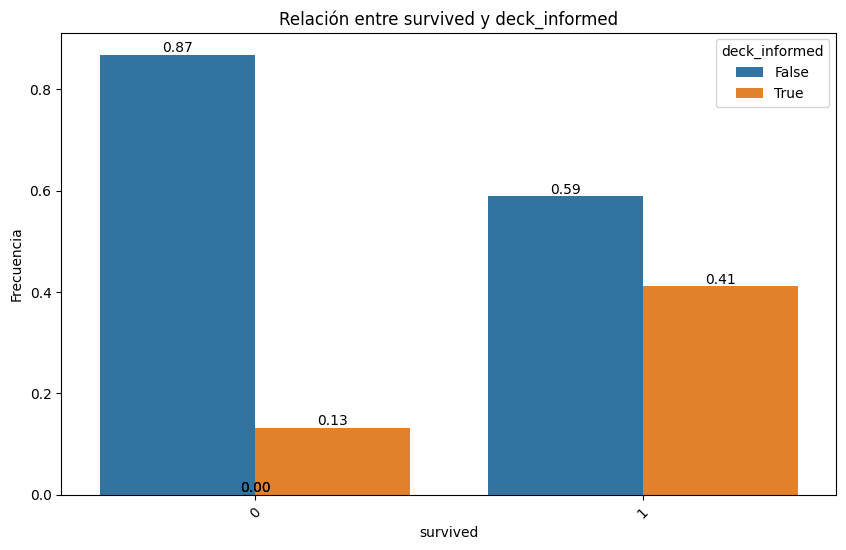

In [91]:
bt.plot_categorical_relationship_fin(train_set, target, "deck_informed", show_values= True, relative_freq=True)

In [ ]:
#los que tienen el KNOWN mueren mas

In [ ]:
#que columnas me quedo:
#quito deck y añado deck_informed

In [ ]:

features_cat.remove("deck")
features_cat.append("deck_informed")

PROCESADO CATEGÓRICO

In [94]:
from sklearn.preprocessing import OrdinalEncoder   

In [95]:
categories = [["female", "male"], ["S", "C", "Q"], ["child", "man", "woman"]]
ordinal_encoder = OrdinalEncoder(categories=categories)

In [96]:
train_set[["sex", "embarked", "who"]] = ordinal_encoder.fit_transform(train_set[["sex", "embarked", "who"]])
test_set[["sex", "embarked", "who"]] = ordinal_encoder.transform(test_set[["sex", "embarked", "who"]])

#lo que hago es ponerle números... hombre 0, mujer 1...

In [97]:
#lo hago porque machine learning no entiende texto, entiende números... entonces lo que hago es decirle que el sexo masculino es 0 y el femenino es 1, por ejemplo... y lo mismo con las otras variables categóricas.

train_set[["sex", "embarked", "who"]]

,sex,embarked,who
455,1.0,1.0,1.0
641,0.0,1.0,2.0
574,1.0,0.0,1.0
463,1.0,0.0,1.0
386,1.0,0.0,0.0
...,...,...,...
797,0.0,0.0,2.0
184,0.0,0.0,0.0
452,1.0,1.0,1.0
339,1.0,0.0,1.0


PROCESADO NUMÉRICO

standarizar


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fare'}>],
       [<Axes: title={'center': 'sibsp'}>, <Axes: >]], dtype=object)

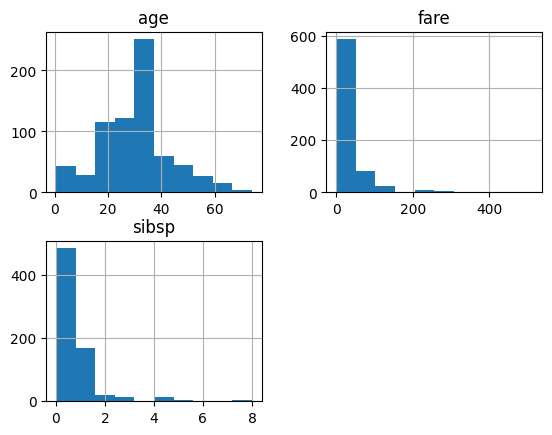

In [98]:
train_set[features_num].hist()

In [ ]:
#fare, cola hacia la derecha
#distribución logaritmica

<Axes: >

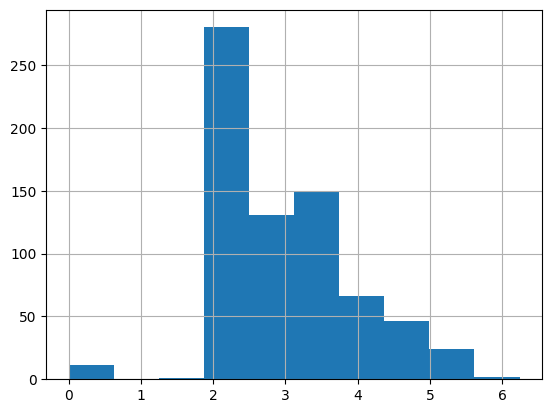

In [99]:
(train_set["fare"]+1).apply(np.log).hist()

<Axes: >

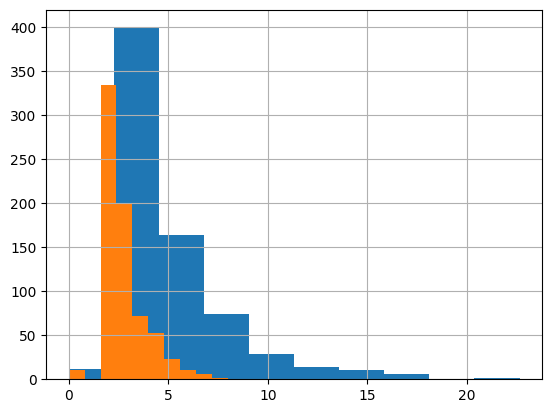

In [101]:
#otra forma

np.sqrt(train_set["fare"]).hist()
np.cbrt(train_set["fare"]).hist()

<Axes: >

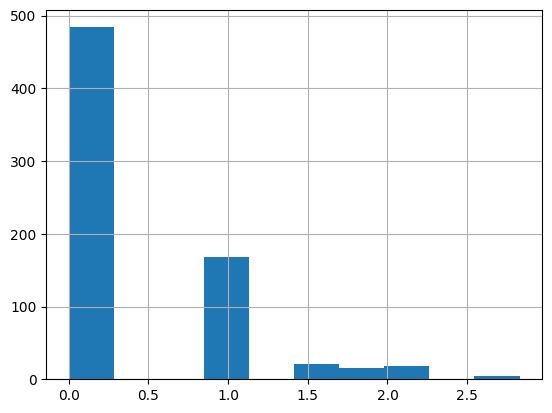

In [102]:
#para sibp

train_set["sibsp"].apply(np.sqrt).hist()

In [104]:
#poner numeros más pequeños

<Axes: >

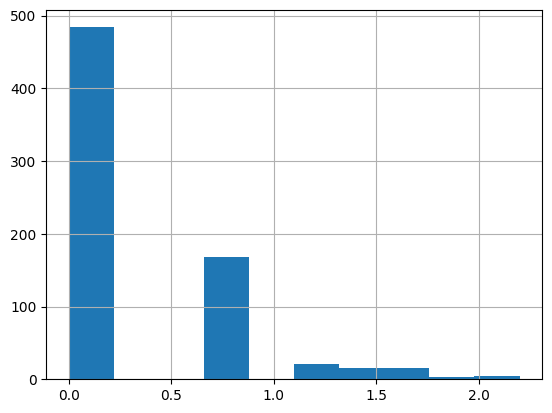

In [ ]:
(train_set["sibsp"]+1).apply(np.log).hist()

#muy parecido al anterior

In [107]:
#aplicamos raíz cuadrada a train y set

train_set["fare"] = np.sqrt(train_set["fare"])
test_set["fare"] = np.sqrt(test_set["fare"])

In [108]:
train_set

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,deck_informed
455,1,3,1.0,29.0,0,0,1.676290,1.0,Third,1.0,True,UNK,Cherbourg,yes,True,False
641,1,1,0.0,24.0,0,0,2.885249,1.0,First,2.0,False,B,Cherbourg,yes,True,True
574,0,3,1.0,16.0,0,0,1.684414,0.0,Third,1.0,True,UNK,Southampton,no,True,False
463,0,2,1.0,48.0,0,0,1.898829,0.0,Second,1.0,True,UNK,Southampton,no,True,False
386,0,3,1.0,1.0,5,2,2.616937,0.0,Third,0.0,False,UNK,Southampton,no,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797,1,3,0.0,31.0,0,0,1.716608,0.0,Third,2.0,False,UNK,Southampton,yes,True,False
184,1,3,0.0,4.0,0,2,2.166352,0.0,Third,0.0,False,UNK,Southampton,yes,False,False
452,0,1,1.0,30.0,0,0,2.295175,1.0,First,1.0,True,C,Cherbourg,no,True,True
339,0,1,1.0,45.0,0,0,2.440940,0.0,First,1.0,True,UNK,Southampton,no,True,False


In [109]:
#ESCALAR

scaler = StandardScaler()
train_set[features_num] = scaler.fit_transform(train_set[features_num])
test_set[features_num] = scaler.transform(test_set[features_num])
train_set.describe()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who
count,711.000000,711.000000,711.000000,7.110000e+02,7.110000e+02,711.000000,7.110000e+02,711.000000,711.000000
mean,0.379747,2.299578,0.644163,2.573344e-16,-7.495177e-18,0.381153,8.194726e-16,0.362869,1.201125
std,0.485665,0.845193,0.479103,1.000704e+00,1.000704e+00,0.813363,1.000704e+00,0.637314,0.603090
min,0.000000,1.000000,0.000000,-2.235400e+00,-4.818043e-01,0.000000,-3.416162e+00,0.000000,0.000000
25%,0.000000,1.000000,0.000000,-5.908805e-01,-4.818043e-01,0.000000,-7.113508e-01,0.000000,1.000000
50%,0.000000,3.000000,1.000000,1.876526e-02,-4.818043e-01,0.000000,-2.699611e-01,0.000000,1.000000
75%,1.000000,3.000000,1.000000,3.997939e-01,4.440413e-01,0.000000,3.912368e-01,1.000000,2.000000
max,1.000000,3.000000,1.000000,3.371817e+00,6.924961e+00,6.000000,4.260550e+00,2.000000,2.000000


In [110]:
test_set.describe()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who
count,178.000000,178.000000,178.000000,138.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0.393258,2.359551,0.668539,0.014486,0.017528,0.387640,-0.048382,0.359551,1.241573
std,0.489851,0.791868,0.472066,1.070052,1.105212,0.782047,1.008471,0.633298,0.555468
min,0.000000,1.000000,0.000000,-2.210252,-0.481804,0.000000,-3.416162,0.000000,0.000000
25%,0.000000,2.000000,0.000000,-0.695663,-0.481804,0.000000,-0.706200,0.000000,1.000000
50%,0.000000,3.000000,1.000000,-0.133646,-0.481804,0.000000,-0.311114,0.000000,1.000000
75%,1.000000,3.000000,1.000000,0.599834,0.444041,0.750000,0.353193,1.000000,2.000000
max,1.000000,3.000000,1.000000,3.829051,6.924961,5.000000,4.260550,2.000000,2.000000


In [ ]:
#con qué variables nos quedamos

features_set_cat_1 = ["pclass", "who"]
features_set_cat_2 = features_cat

MODELADO

In [112]:
x_train = train_set[features_set_cat_1]
y_train = train_set[target]

x_test = test_set[features_set_cat_1]
y_test = test_set[target]

In [113]:
log_class_1 = LogisticRegression(max_iter=1000)  #hiperparametros
log_class_1.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
#PREDICCIONES

In [114]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [115]:
def metrics_titanic(model, X, y_target):
    y_pred = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y_target, y_pred)
    print(classification_report(y_target, y_pred))  

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       441
           1       0.68      0.58      0.62       270

    accuracy                           0.73       711
   macro avg       0.72      0.70      0.71       711
weighted avg       0.73      0.73      0.73       711



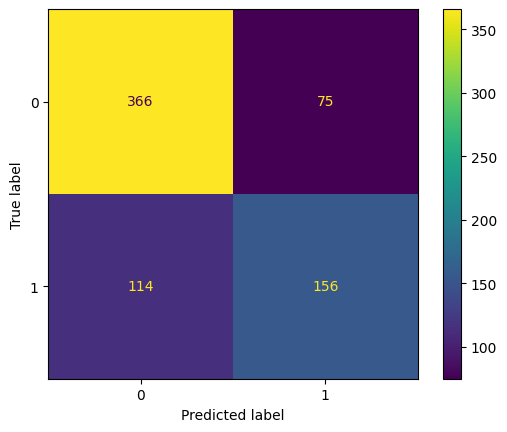

In [116]:
metrics_titanic(log_class_1, x_train, y_train)

              precision    recall  f1-score   support

           0       0.73      0.91      0.81       108
           1       0.77      0.47      0.58        70

    accuracy                           0.74       178
   macro avg       0.75      0.69      0.70       178
weighted avg       0.74      0.74      0.72       178



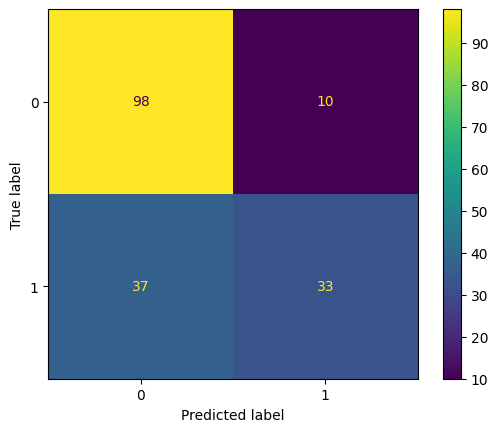

In [117]:
metrics_titanic(log_class_1, x_test, y_test)

Accuracy = porcentaje de acierto

In [ ]:
#otra mética: CURVA ROC

AUROC: 0.72


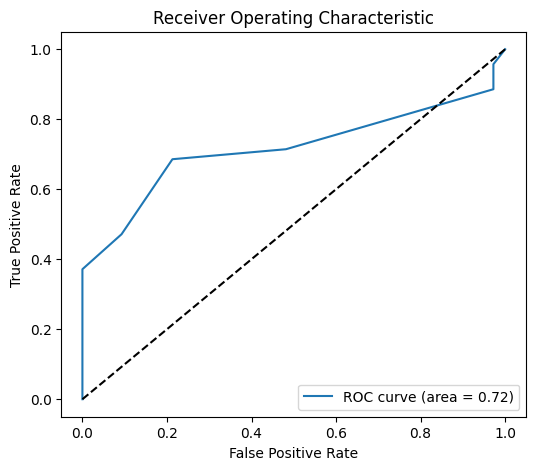

In [121]:
from sklearn.metrics import roc_curve, auc
scores = log_class_1.predict_proba(x_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:, 1])
roc_auc = auc(fpr, tpr)
print("AUROC: %.2f" % (roc_auc))
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()